In [19]:
#Copyright (c) 2023 John Simonis and The Ohio State University. All rights reserved.
#This code was written by John Simonis for a research project at The Ohio State University.

#This is what we use for our equations of best fit.
from pysr import PySRRegressor

#Necessary for handling symbolic outputs of pysr.
import sympy

#Let us import data into a dataframe.
import pandas as pd

#Arrays, interpolation, and analysis.
import numpy as np

#Needed for plotting.
from matplotlib import pyplot as plt

#Needed for data skew.
import scipy as sp

#This is a dictionary of a handful of customized PYSR terms, see here https://astroautomata.com/PySR/
default_pysr_params = dict(
    populations=50,
    model_selection="accuracy",
    population_size=100,
    niterations=100,
    binary_operators=["+", "*", "^"],
    unary_operators=["sin", "cos", "exp", "log", "erf", "ceil", "floor"],
    maxsize=50,
    ncycles_per_iteration=100,
    progress=False,
    procs=10,
    variable_names=["x", "y"],
)

#Control Dataset
Control_XLS = pd.ExcelFile("../Control/DessicantControlTests.xlsx")
Control_Dataframe = pd.read_excel(Control_XLS, sheet_name="Average")

#Proto Dataset
Proto_XLS = pd.ExcelFile("../Proto/ProtoTests.xlsx")
Proto_Dataframe = pd.read_excel(Proto_XLS, sheet_name="Average")

#Dep Control Dataset
DepControl_XLS = pd.ExcelFile("../Deprecated/DCTests.xlsx")
DepControl_Dataframe = pd.read_excel(
    DepControl_XLS,
    sheet_name="Average",
    names=[
        "Amps (A)",
        "Water Level (mL)",
        "Volts (V)",
        "WattHours (WH)",
        "Temp (C)",
        "Relative Humidity (%)",
        "Cumulative WattHours (WH)",
    ],
)

#Dep Proto Dataset
DepProto_XLS = pd.ExcelFile("../Deprecated/DPTests.xlsx")
DepProto_Dataframe = pd.read_excel(
    DepProto_XLS,
    sheet_name="Average",
    names=[
        "Amps (A)",
        "Water Level (mL)",
        "Volts (V)",
        "WattHours (WH)",
        "Temp (C)",
        "Relative Humidity (%)",
        "Cumulative WattHours (WH)",
    ],
)


#Control Variables
C_x = Control_Dataframe["Cumulative WattHours (WH)"].to_numpy().reshape(-1, 1)
C_y = Control_Dataframe["Water Level (mL)"].to_numpy()
C_z = Control_Dataframe["Temp (C)"].to_numpy()

#Proto Variables
P_x = Proto_Dataframe["Cumulative WattHours (WH)"].to_numpy().reshape(-1, 1)
P_y = Proto_Dataframe["Water Level (mL)"].to_numpy()
P_z = Proto_Dataframe["Temp (C)"].to_numpy()

#Dep Control Variables
DC_x = (
    pd.to_numeric(
        DepControl_Dataframe["Cumulative WattHours (WH)"].str.replace(" WH", "")
    )
    .to_numpy()
    .reshape(-1, 1)
)

DC_y = pd.to_numeric(DepControl_Dataframe["Water Level (mL)"].str.replace(" mL", "")).to_numpy()
DC_z = pd.to_numeric(DepControl_Dataframe["Temp (C)"].str.replace(" C", "")).to_numpy()

#Dep Proto Variables
DP_x = (
    pd.to_numeric(
        DepProto_Dataframe["Cumulative WattHours (WH)"].str.replace(" WH", "")
    )
    .to_numpy()
    .reshape(-1, 1)
)

DP_y = pd.to_numeric(DepProto_Dataframe["Water Level (mL)"].str.replace(" mL", "")).to_numpy()
DP_z = pd.to_numeric(DepProto_Dataframe["Temp (C)"].str.replace(" C", "")).to_numpy()

def analysis(data):
    data_headers = ["Vertical Power", "Vertical Temp", "Vertical Amp", "Vertical Water"]
    for i in range(0, 4):
        print(data_headers[i], "STDDEV:", np.std(data[i]))
        print(data_headers[i], "MEDIAN:", np.median(data[i]))
        print(data_headers[i], "SKEW:", sp.stats.skew(data[i]), "\n")

## Dessicant Wheel Control
The Control Water Harvester utilizes a desiccant wheel design, leveraging a heat lamp to dry out pockets of desiccant and a fan to circulate heated air through the silica gel desiccant.

In [20]:
#Pass in the fitting parameters
Control_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
Control_Equations.fit(C_x, C_y)

/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:1290: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:73: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 4.130e+05
Head worker occupation: 15.3%
Progress: 1190 / 5000 total iterations (23.800%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           6.065e+01  1.594e+01  y = 1.2045
2           1.757e+01  1.239e+00  y = exp(2.0501)
3           1.614e-01  4.690e+00  y = x₀ * 0.16431
4           1.445e-01  1.110e-01  y = 0.16304 * ceil(x₀)
5           1.022e-01  3.459e-01  y = (x₀ + 3.1247) * 0.15642
6           8.991e-02  1.284e-01  y = exp((0.096152 * x₀) ^ 0.46392)
7           7.692e-02  1.560e-01  y = ((x₀ + 6.753) * 0.12035) ^ 1.0963
8           5.915e-02  2.626e-01  y = (exp(x₀ ^ 0.37132) * 0.43167) ^ 0.60559
9           5.211e-02  1.268e-01  y = floor(exp(x₀ ^ 0.37118) * 0.43492) ^ 0.60591
10          4.725e-02  9.804e-02  y = floor(floor(exp(x₀ ^ 0.37175)) * 0.49014) ^ 0.58825
11          4.494e-02  4.995e-02  y = ((exp(x₀ ^ erf(0.36817)) 

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          1.2044799   
	1         1.239116                                     exp(2.0500836)   
	2         4.689684                                     x0 * 0.1643142   
	3         0.111044                              0.16303702 * ceil(x0)   
	4         0.345900                      (x0 + 3.1247077) * 0.15641728   
	5         0.128380                 exp((0.0961519 * x0) ^ 0.46392283)   
	6         0.337442               (1.0161471 ^ x0) + (x0 * 0.11738814)   
	7         0.314694            (x0 * 0.17440854) + cos(1.0161471 ^ x0)   
	8         0.093722        (x0 * 0.1734737) + erf(cos(1.0161811 ^ x0))   
	9         0.011895  (x0 * 0.17333212) + erf(cos(1.0163056 ^ floor(...   
	10        0.049196  (1.1331964 * erf(cos(1.0161278 ^ x0))) + (x0 *...   
	11        0.001916  (1.1331964 * erf(cos(1.0161278 ^ floor(x0)))) ...   
	12        0.012736  (x0 * 0.17440854) + erf((1.1331964 ^ 1.5741419...   
	13        0.008404  ((x0 + sin(0.0961519 * x0)) * 0.17430277) + co...   
	14        0.009100  ((floor(exp(x0 ^ erf(0.36816654))) + (sin(x0) ...   
	15        0.077077  ((x0 + sin(0.0961519 * x0)) * 0.17430277) + co...   
	16        0.004152  (0.17430277 * (x0 + sin(0.0961519 * x0))) + co...   
	17        0.012156  (0.17533527 * (x0 + sin(x0 ^ exp(floor(sin(x0 ...   
	18        0.064222  (0.17533527 * (x0 + sin(x0 ^ exp(floor(sin(cei...   
	19        0.032555  (0.17533527 * (x0 + sin(x0 ^ exp(floor(cos(flo...   
	20        0.024220  (0.17533527 * (x0 + sin(x0 ^ exp(floor(cos(flo...   
	21        0.002741  (0.17533527 * (x0 + sin(x0 ^ exp(floor(cos(flo...   
	22        0.008006  (0.17533527 * (x0 + sin(x0 ^ exp(floor(sin(log...   
	23        0.009088  ((x0 + sin(x0 ^ exp(floor(sin(log(ceil(x0 ^ er...   
	24        0.000044  (0.17533527 * (x0 + sin(x0 ^ exp(floor(sin(log...   
	25        0.001701  (0.17533527 * ((x0 + sin(x0 ^ exp(floor(sin(lo...   
	26  >>>>  0.000092  (0.17533527 * ((x0 + sin(x0 ^ exp(floor(sin(lo...   
	
	         loss  complexity  
	0   60.654630           1  
	1   17.568020           2  
	2    0.161443           3  
	3    0.144475           4  
	4    0.102228           5  
	5    0.089912           6  
	6    0.064160           7  
	7    0.046838           8  
	8    0.042648           9  
	9    0.042143          10  
	10   0.040120          11  
	11   0.040043          12  
	12   0.039537          13  
	13   0.039206          14  
	14   0.038851          15  
	15   0.035969          16  
	16   0.035820          17  
	17   0.035387          18  
	18   0.033186          19  
	19   0.032123          20  
	20   0.031354          21  
	21   0.031268          22  
	22   0.030772          24  
	23   0.030493          25  
	24   0.030488          29  
	25   0.030436          30  
	26   0.030428          33  
]

Vertical Power STDDEV: 0.003055499438317472
Vertical Power MEDIAN: 0.5133333333333333
Vertical Power SKEW: 0.1908440289314235 

Vertical Temp STDDEV: 2.9918445133812783
Vertical Temp MEDIAN: 27.08
Vertical Temp SKEW: 0.00830511957701228 

Vertical Amp STDDEV: 0.023454447576336378
Vertical Amp MEDIAN: 7.713333333333334
Vertical Amp SKEW: -0.10235233214597493 

Vertical Water STDDEV: 4.191422343549114
Vertical Water MEDIAN: 7.333333333333333
Vertical Water SKEW: 0.13485310695774946 

0.175 x_{0} + 0.175 \sin{\left(x_{0}^{e^{\left\lfloor{\sin{\left(\log{\left(\left(x_{0} + \cos{\left(x_{0} + \operatorname{erf}{\left(x_{0} \right)} \right)}\right)^{\sin{\left(\operatorname{erf}{\left(x_{0} \right)} \right)}} \right)} \right)}}\right\rfloor}} \right)} + \operatorname{erf}{\left(1.13 \sin{\left(\cos{\left({1.02}^{x_{0}} \right)} \right)} \right)} + 0.0140


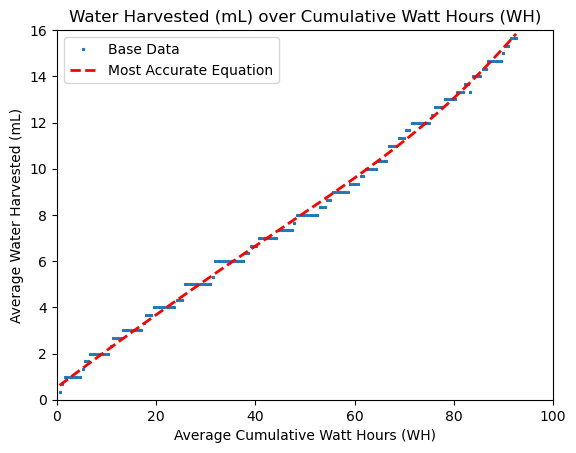

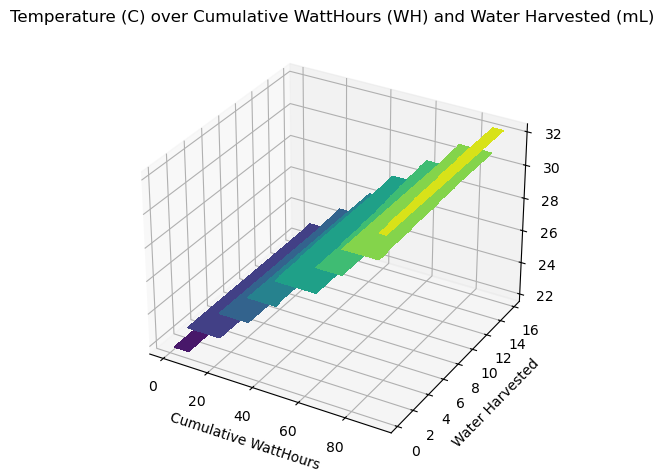

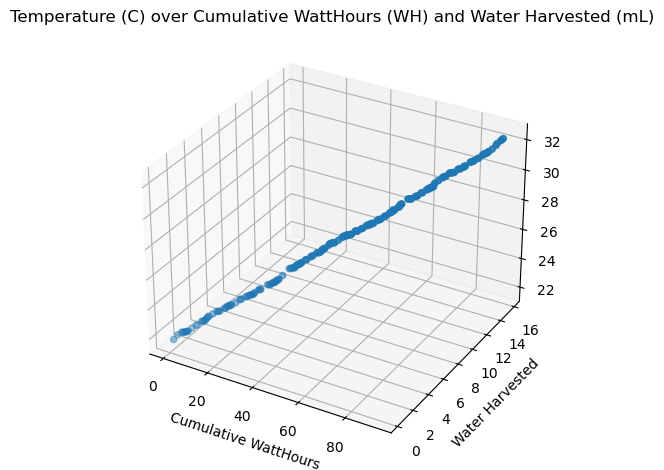

In [21]:
#Basic scatter plot
plt.plot(
    C_x,
    C_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = Control_Equations.equations_.query(
    f"loss < {2 * Control_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    C_x,
    Control_Equations.predict(C_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 100])
plt.ylim([0, 16])
analysis(
    [
        Control_Dataframe["WattHours (WH)"].to_numpy(),
        C_z,
        Control_Dataframe["Amps (A)"].to_numpy(),
        C_y,
    ]
)
print(Control_Equations.latex())

#3D scatterplot and contour plot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
C_X, C_Y = np.meshgrid(C_x,C_y)
C_Z = sp.interpolate.griddata(np.column_stack((C_x.reshape(-1,1),C_y)), C_z, (C_X, C_Y), method = "nearest")
plt.contourf(C_x.reshape(-1),C_y,C_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(C_x,C_y,C_z)

# NiTi Prototype
The NiTi prototype employs a straightforward gantry system, powered by a high torque stepper motor. A T8 leadscrew is incorporated for a simple mechanical advantage to apply stress to the NiTi wires.

In [22]:
#Run PySR
Proto_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
Proto_Equations.fit(P_x, P_y)

/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:1290: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:73: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 4.230e+05
Head worker occupation: 17.9%
Progress: 1225 / 5000 total iterations (24.500%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           5.620e+02  1.594e+01  y = x₀
2           6.920e+00  4.397e+00  y = exp(1.5801)
3           6.963e-02  4.599e+00  y = 0.18877 * x₀
4           6.273e-02  1.043e-01  y = ceil(x₀) * 0.18592
5           4.099e-02  4.255e-01  y = (0.2275 * x₀) ^ 0.91124
6           4.099e-02  8.941e-07  y = (sin(0.22948) * x₀) ^ 0.91129
7           3.855e-02  6.136e-02  y = (0.21219 + (x₀ * -0.00061891)) * x₀
8           3.854e-02  3.386e-04  y = x₀ * ((floor(x₀) * -0.00061783) + 0.21186)
10          3.834e-02  2.513e-03  y = x₀ * (((x₀ + cos(x₀)) * -0.00062316) + 0.2126)
11          2.898e-02  2.802e-01  y = (0.24447 * (floor(cos(0.92305 * x₀)) + x₀)) ^ 0.88705
12          2.859e-02  1.339e-02  y = ((x₀ + floor(cos(x₀ *

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                         0.62105787   
	1         1.278494                                     exp(1.5800935)   
	2         4.599025                                    0.18877153 * x0   
	3         0.104332                               ceil(x0) * 0.1859235   
	4         0.425466                      (0.22749804 * x0) ^ 0.9112427   
	5         0.000001                 (0.22745405 * x0) ^ erf(1.2038642)   
	6         0.061361          x0 * ((x0 * -0.00061890425) + 0.21219456)   
	7         0.000338    x0 * ((floor(x0) * -0.00061783125) + 0.2118611)   
	8         0.147536  (0.23007926 * (cos(x0 ^ 0.97608864) + x0)) ^ 0...   
	9         0.026667  (0.24446538 * (floor(cos(x0 ^ 0.97608864)) + x...   
	10        0.055058  (cos(x0 ^ 0.97608864) + x0) * ((x0 * -0.000623...   
	11        0.001094  ((floor(cos((cos(-0.4406782) * x0) + erf(exp(c...   
	12        0.011872  (0.24446538 * (floor(cos((cos(-0.44081494) * x...   
	13        0.000969  (0.24446538 * (x0 + floor(cos(((x0 * cos(-0.44...   
	14        0.016999  (0.24446538 * (x0 + floor(cos(((x0 * cos(-0.44...   
	15        0.011428  ((x0 + (floor(cos(((x0 * cos(-0.44081494)) + -...   
	16        0.001261  (((x0 + (floor(cos(((x0 * cos(-0.44081494)) + ...   
	17        0.000270  (((x0 + (floor(cos(((x0 * cos(-0.44081494)) + ...   
	18        0.003146  (((x0 + (floor(floor(cos(((x0 * cos(-0.4408149...   
	19        0.001648  (((x0 + (floor(floor(cos(((x0 * cos(-0.4408149...   
	20  >>>>  0.003498  (((x0 + ((ceil(floor(cos(((x0 * cos(-0.4408149...   
	
	         loss  complexity  
	0   24.850847           1  
	1    6.919876           2  
	2    0.069625           3  
	3    0.062727           4  
	4    0.040990           5  
	5    0.040990           6  
	6    0.038550           7  
	7    0.038537           8  
	8    0.028690          10  
	9    0.027935          11  
	10   0.026439          12  
	11   0.026266          18  
	12   0.025956          19  
	13   0.025906          21  
	14   0.025469          22  
	15   0.024893          24  
	16   0.024737          29  
	17   0.024730          30  
	18   0.024653          31  
	19   0.024612          32  
	20   0.024440          34  
]

Vertical Power STDDEV: 0.2785496658115589
Vertical Power MEDIAN: 0.27
Vertical Power SKEW: 0.0014724439344308453 

Vertical Temp STDDEV: 0.14768078479453892
Vertical Temp MEDIAN: 23.511666666666663
Vertical Temp SKEW: -0.04108905149599962 

Vertical Amp STDDEV: 4.179428089587817
Vertical Amp MEDIAN: 4.045
Vertical Amp SKEW: 0.0012824667441691305 

Vertical Water STDDEV: 2.6305658218736663
Vertical Water MEDIAN: 5.0
Vertical Water SKEW: -0.11995470090320919 

\left(\left({0.214}^{x_{0}} + x_{0} + \left(\left\lfloor{\cos{\left(x_{0} \cos{\left(-0.441 \right)} + e^{\sin{\left(\left\lfloor{\operatorname{erf}{\left(\cos{\left(e^{\left\lfloor{x_{0}}\right\rfloor} \right)} \right)}}\right\rfloor \right)}} - 0.0568 \right)}}\right\rfloor + 0.0461\right) 1.22\right) 0.244\right)^{0.887}


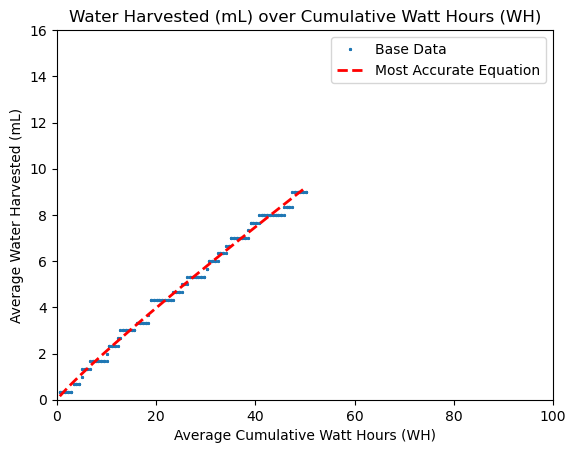

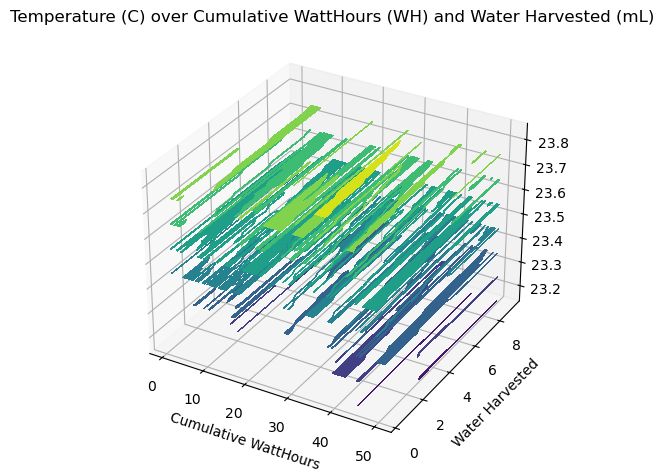

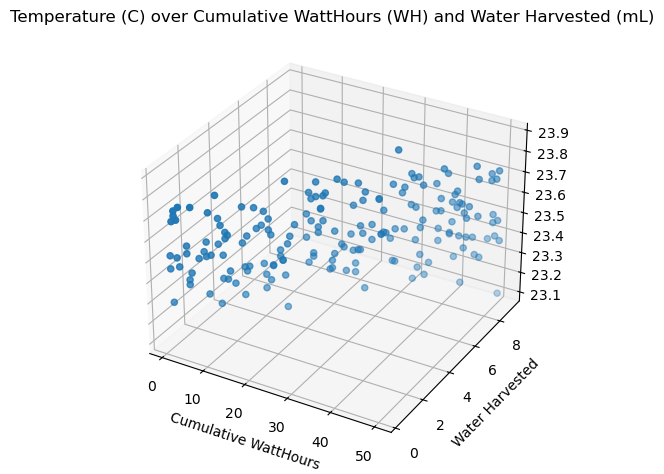

In [23]:
#Basic scatter plot
plt.plot(
    P_x,
    P_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = Proto_Equations.equations_.query(
    f"loss < {2 * Proto_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    P_x,
    Proto_Equations.predict(P_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 100])
plt.ylim([0, 16])
analysis(
    [
        Proto_Dataframe["WattHours (WH)"].to_numpy(),
        P_z,
        Proto_Dataframe["Amps (A)"].to_numpy(),
        P_y,
    ]
)
print(Proto_Equations.latex())

#3D scatterplot and contour plot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours", loc="left")
plt.ylabel("Water Harvested")
fig.tight_layout()
P_X, P_Y = np.meshgrid(P_x,P_y)
P_Z = sp.interpolate.griddata(np.column_stack((P_x.reshape(-1,1),P_y)), P_z, (P_X, P_Y), method = "nearest")
plt.contourf(P_x.reshape(-1),P_y,P_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(P_x,P_y,P_z)

# Deprecated Designs
The Peltier device is first and then the first NiTi prototype is second.

In [24]:
#Run PySR
DepControl_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
DepControl_Equations.fit(DC_x,DC_y)

/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:1290: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:73: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.510e+05
Head worker occupation: 26.1%
Progress: 837 / 5000 total iterations (16.740%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           9.991e+00  1.594e+01  y = -0.2791
2           1.611e-01  4.127e+00  y = log(x₀)
4           1.377e-01  7.849e-02  y = log(x₀) + -0.15299
5           1.325e-01  3.857e-02  y = ceil(-0.53394 + log(x₀))
6           1.187e-01  1.100e-01  y = (log(x₀) * 1.1538) + -0.5898
7           7.773e-02  4.232e-01  y = log(x₀) * erf(x₀ * 0.0969)
8           7.721e-02  6.757e-03  y = erf(0.092949 * x₀) * log(ceil(x₀))
9           6.962e-02  1.035e-01  y = (sin(x₀ * -0.26979) * 0.41878) + log(x₀)
10          6.262e-02  1.060e-01  y = cos(erf(-19.564 * (0.71068 ^ x₀))) * log(x₀)
11          4.709e-02  2.850e-01  y = ((sin(-0.27185 * x₀) + -0.36116) * 0.41729) + log(x₀)
12          4.388e-02  7.045e-02  y = (-0.80383 + 

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                        -0.27909648   
	1         4.127367                                            log(x0)   
	2         0.078492                              log(x0) + -0.15298997   
	3         0.052157                          ceil(-0.553916 + log(x0))   
	4         0.096451                 (log(x0) * 1.1537647) + -0.5897972   
	5         0.423230                     erf(0.09688988 * x0) * log(x0)   
	6         0.006757               erf(0.09294857 * x0) * log(ceil(x0))   
	7         0.103491     (sin(-0.26979446 * x0) * 0.41849637) + log(x0)   
	8         0.130350    cos(erf((0.6132002 ^ x0) * 89.40486)) * log(x0)   
	9         0.260653  ((sin(-0.27188656 * x0) + -0.3608739) * 0.4177...   
	10        0.099560  log(x0) + (-0.8561081 + erf(sin(-0.2608122 * x...   
	11        0.079678  log(x0) + (-0.8525775 + erf(sin(-0.26663998 * ...   
	12        0.234209  (sin(-0.14045726 * x0) * (0.2697765 + cos(-0.1...   
	13        0.144030  (sin(-0.14130759 * x0) * (cos(x0 * -0.12513839...   
	14        0.272916  log(x0) + ((sin(exp(cos(x0 * 0.14888018))) ^ 2...   
	15        0.029623  log(x0) + ((sin(exp(erf(cos(-0.1512758 * x0)))...   
	16        0.091393  (((sin(exp(cos(x0 * -0.14664322))) ^ 2.2215567...   
	17        0.154314  -0.11631603 + (log(ceil(x0)) + (sin(-0.2706126...   
	18        0.442060  (log(ceil(x0)) + (sin(-0.27195272 * x0) * (sin...   
	19        0.137701  (log(ceil(x0)) + (erf(sin(-0.2723618 * x0)) * ...   
	20        0.059251  -0.15530461 + (((sin(exp(erf(cos(x0 * -0.14672...   
	21        0.001849  -0.15530461 + (((sin(exp(erf(cos(x0 * sin(-0.1...   
	22        0.037291  -0.14240837 + ((sin(erf(sin(-0.27244958 * x0))...   
	23        0.023240  -0.14240837 + ((erf(erf(sin(-0.27244958 * x0))...   
	24        0.043733  (log(x0 + 0.8992727) + ((sin(exp(erf(erf(cos(-...   
	25        0.009622  (log(x0 + 0.8992727) + ((sin(exp(erf(erf(cos(-...   
	26        0.034255  (log(x0 + 0.8290655) + ((erf(erf(erf(sin(x0 * ...   
	27        0.006998  (log(ceil(x0) + cos(floor(-0.13181596))) + ((e...   
	28        0.035561  -0.1426456 + (log(cos(floor(-0.13181596)) + ce...   
	29        0.010784  -0.116821855 + (((sin(exp(erf(sin(cos(x0 * -0....   
	30        0.004342  -0.116821855 + (((sin(exp(erf(sin(cos(x0 * -0....   
	31        0.022558  -0.098631516 + (log(x0 + erf((x0 + floor(-0.44...   
	32        0.023190  -0.098631516 + (log(x0 + erf((x0 + floor(erf(-...   
	33        0.000501  -0.098631516 + (log(x0 + erf((x0 + floor(sin(e...   
	34        0.014157  -0.098631516 + (log(x0 + erf((x0 + floor(erf(-...   
	35        0.006862  -0.098631516 + (log(x0 + erf((x0 + floor(erf(-...   
	36        0.013251  -0.098631516 + (log(x0 + erf((x0 + floor(erf(-...   
	37        0.001846  sin(-0.098631516) + (log(x0 + erf((x0 + floor(...   
	38  >>>>  0.005428  sin(-0.098631516) + (log(x0 + erf((x0 + floor(...   
	
	        loss  complexity  
	0   9.991064           1  
	1   0.161109           2  
	2   0.137703           4  
	3   0.130704           5  
	4   0.118687           6  
	5   0.077731           7  
	6   0.077208           8  
	7   0.069617           9  
	8   0.061109          10  
	9   0.047087          11  
	10  0.042625          12  
	11  0.039361          13  
	12  0.031142          14  
	13  0.026965          15  
	14  0.020524          16  
	15  0.019925          17  
	16  0.018185          18  
	17  0.015585          19  
	18  0.010016          20  
	19  0.008728          21  
	20  0.008226          22  
	21  0.008211          23  
	22  0.007910          24  
	23  0.007728          25  
	24  0.007398          26  
	25  0.007327          27  
	26  0.007080          28  
	27  0.006933          31  
	28  0.006691          32  
	29  0.006408          36  
	30  0.006381          37  
	31  0.006238          38  
	32  0.006095          39  
	33  0.006092          40  
	34  0.006006          41  
	

Vertical Power STDDEV: 0.003346364051814961
Vertical Power MEDIAN: 0.25
Vertical Power SKEW: -2.2203703729531203 

Vertical Temp STDDEV: 0.10611890293381486
Vertical Temp MEDIAN: 22.8
Vertical Temp SKEW: -0.10926708348002251 

Vertical Amp STDDEV: 0.027706118013451422
Vertical Amp MEDIAN: 3.73
Vertical Amp SKEW: 0.06975514771080801 

Vertical Water STDDEV: 1.0906223289417172
Vertical Water MEDIAN: 3.0
Vertical Water SKEW: -0.7987799534398714 

\left(- \operatorname{erf}{\left(\operatorname{erf}{\left(\operatorname{erf}{\left(\operatorname{erf}{\left(\sin{\left(0.275 x_{0} \right)} \right)} \right)} \right)} \right)} - 0.155\right) \sin^{2.22}{\left(e^{\operatorname{erf}{\left(\sin{\left(\cos{\left(0.145 x_{0} \right)} \right)} \right)}} \right)} + \log{\left(x_{0} + \operatorname{erf}{\left(\left(x_{0} + \left\lfloor{- 0.472 x_{0}}\right\rfloor\right)^{\left\lceil{x_{0} \sin{\left(\left\lfloor{\cos{\left(\left\lceil{x_{0}}\right\rceil \right)}}\right\rfloor \right)}}\right\rceil} \righ

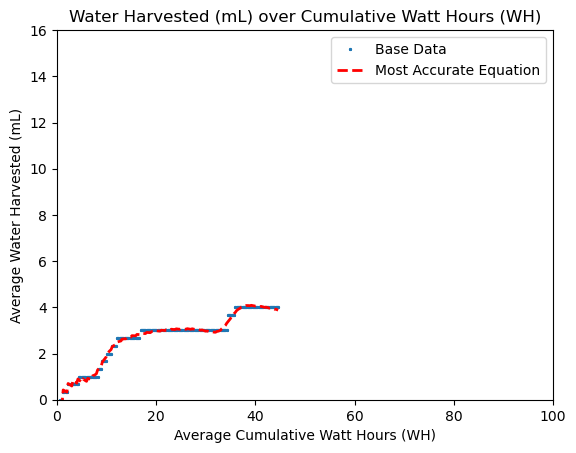

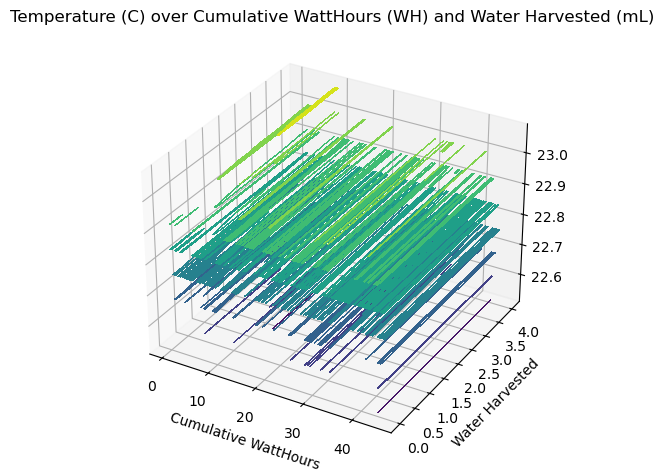

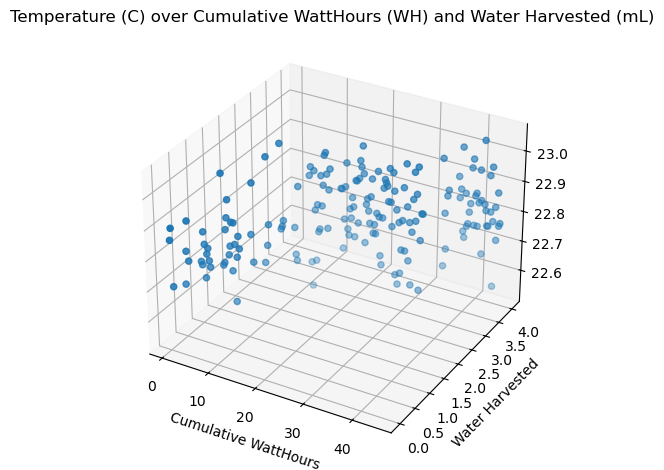

In [25]:
#Basic scatter plot
plt.plot(
    DC_x,
    DC_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = DepControl_Equations.equations_.query(
    f"loss < {2 * DepControl_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    DC_x,
    DepControl_Equations.predict(DC_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 100])
plt.ylim([0, 16])
analysis(
    [
        pd.to_numeric(
            DepControl_Dataframe["WattHours (WH)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DC_z,
        pd.to_numeric(
            DepControl_Dataframe["Amps (A)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DC_y,
    ]
)
print(DepControl_Equations.latex())

#3D scatterplot and contour plot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours", loc="left")
plt.ylabel("Water Harvested")
fig.tight_layout()
DC_X, DC_Y = np.meshgrid(DC_x,DC_y)
DC_Z = sp.interpolate.griddata(np.column_stack((DC_x.reshape(-1,1),DC_y)), DC_z, (DC_X, DC_Y), method = "nearest")
plt.contourf(DC_x.reshape(-1),DC_y,DC_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(DC_x,DC_y,DC_z)

In [26]:
#Run PySR
DepProto_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
DepProto_Equations.fit(DP_x,DP_y)

/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:1290: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:73: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 3.580e+05
Head worker occupation: 19.2%
Progress: 1076 / 5000 total iterations (21.520%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           1.829e+03  1.594e+01  y = x₀
2           6.219e-01  7.986e+00  y = log(x₀)
3           1.258e-01  1.598e+00  y = 0.073674 * x₀
4           1.168e-01  7.434e-02  y = 0.073023 * ceil(x₀)
5           3.373e-02  1.242e+00  y = (0.11669 * x₀) ^ 0.7556
7           3.307e-02  9.960e-03  y = ((x₀ + 1.0123) * 0.10817) ^ 0.77899
8           3.307e-02  7.749e-06  y = (0.10816 * (x₀ + ceil(0.052705))) ^ 0.77899
9           3.047e-02  8.180e-02  y = ((0.11707 * x₀) ^ 0.75419) + (0.35633 ^ x₀)
10          2.706e-02  1.187e-01  y = (0.11432 * (sin(0.32 * x₀) + x₀)) ^ 0.76185
11          2.545e-02  6.131e-02  y = (0.11668 * (x₀ + sin(ceil(0.32 * x₀)))) ^ 0.75549
13          2.217e-02  6.902e-02  y = (-0.056706 * (x

PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                                 x0   
	1         7.986707e+00                                            log(x0)   
	2         1.598349e+00                                    0.07367398 * x0   
	3         7.433680e-02                             0.073023334 * ceil(x0)   
	4         1.241634e+00                      (0.11663496 * x0) ^ 0.7557768   
	5         5.039921e-07                 (x0 * sin(0.11688319)) ^ 0.7558279   
	6         2.005710e-02        (0.10734096 * (x0 + 1.0812409)) ^ 0.7819184   
	7         2.550886e-02   (ceil(x0 * 1.1592311) * 0.09803715) ^ 0.76208746   
	8         9.206794e-02  ((0.11528975 * x0) ^ 0.76049095) + (0.53242946...   
	9         1.270891e-01  (0.11564411 * (sin(0.3302421 * x0) + x0)) ^ 0....   
	10        1.965492e-02  (0.11563647 * (x0 + sin(ceil(0.31641376 * x0))...   
	11        2.150166e-02  0.92655265 + ((x0 * erf((-0.09838135 * x0) + 1...   
	12        1.331506e-01  (0.11563647 * (x0 + (sin(ceil(0.31641376 * x0)...   
	13        9.881652e-03  (0.11563647 * (x0 + (sin(ceil(0.31641376 * cei...   
	14        2.271134e-03  (0.11563647 * (x0 + (sin(ceil(0.31641376 * cei...   
	15        6.929315e-02  0.9814347 + (ceil(1.0535164 * ceil(x0 * erf(0....   
	16        1.407932e-01  0.9379724 + ((erf(ceil(-0.13465819 * x0) + 0.9...   
	17        6.662724e-03  0.9379724 + ((erf(ceil((-0.13465819 * x0) + ce...   
	18        6.568137e-02  (-0.122964226 * (0.4614657 * ((x0 + sin(x0 ^ 0...   
	19        2.796091e-03  (-0.122288376 * (0.4649585 * ((sin(ceil(x0) ^ ...   
	20        2.857305e-02  0.9583245 + (-0.05622429 * (erf(ceil(ceil(0.20...   
	21        2.293415e-01  (-0.12073644 * ((((sin(x0 ^ 0.798607) * exp(0....   
	22        2.209762e-02  (-0.122288376 * (0.4649585 * (((sin(ceil(x0) ^...   
	23        1.469341e-03  (-0.12240255 * ((((sin((x0 + 0.7963989) ^ 0.79...   
	24        2.322274e-02  (-0.12073644 * (0.4649473 * (((sin((x0 + cos(x...   
	25        2.043254e-02  (-0.12073644 * ((((sin((x0 + sin(ceil(x0))) ^ ...   
	26        6.874235e-02  0.9502211 + ((((x0 + (sin((x0 + sin(x0 * -0.13...   
	27        5.997133e-03  (-0.121111386 * (((x0 + (sin((x0 + exp(sin(cei...   
	28        2.481018e-03  (-0.121111386 * (((x0 + (sin((x0 + exp(sin(cei...   
	29  >>>>  2.104283e-03  (-0.121111386 * (((x0 + (sin(((x0 + exp(sin(ce...   
	
	           loss  complexity  
	0   1829.283700           1  
	1      0.621868           2  
	2      0.125760           3  
	3      0.116751           4  
	4      0.033731           5  
	5      0.033731           6  
	6      0.033061           7  
	7      0.032228           8  
	8      0.029394           9  
	9      0.025886          10  
	10     0.025382          11  
	11     0.024842          12  
	12     0.021745          13  
	13     0.021531          14  
	14     0.021433          16  
	15     0.019999          17  
	16     0.017372          18  
	17     0.017257          19  
	18     0.016160          20  
	19     0.016115          21  
	20     0.015661          22  
	21     0.012451          23  
	22     0.012179          24  
	23     0.012161          25  
	24     0.011882          26  
	25     0.011642          27  
	26     0.010868          28  
	27     0.010674          31  
	28     0.010622          33  
	29     0.010577          35  
]

Vertical Power STDDEV: 0.014679880518742925
Vertical Power MEDIAN: 0.44
Vertical Power SKEW: -0.09197059749850972 

Vertical Temp STDDEV: 0.15856514246117498
Vertical Temp MEDIAN: 25.01
Vertical Temp SKEW: -0.0984512551837561 

Vertical Amp STDDEV: 0.21317526595982159
Vertical Amp MEDIAN: 6.61
Vertical Amp SKEW: -0.07791209416425922 

Vertical Water STDDEV: 1.4485566224712627
Vertical Water MEDIAN: 3.33
Vertical Water SKEW: -0.2322940059788474 

\left(-0.121\right) \left(x_{0} + e^{0.983} \sin{\left(\left(x_{0} + e^{\sin{\left(\left\lceil{x_{0}}\right\rceil \left(-0.133\right) \right)}} - 0.159\right)^{0.795} \right)}\right) \operatorname{erf}{\left(\left\lceil{- 0.132 x_{0}}\right\rceil + 0.929 \right)} 0.465 + {0.931}^{0.804}


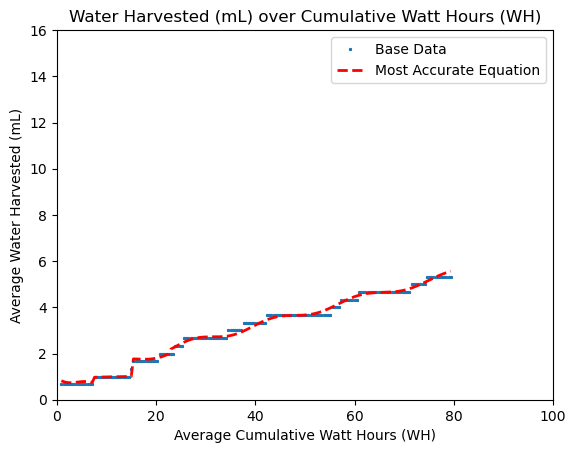

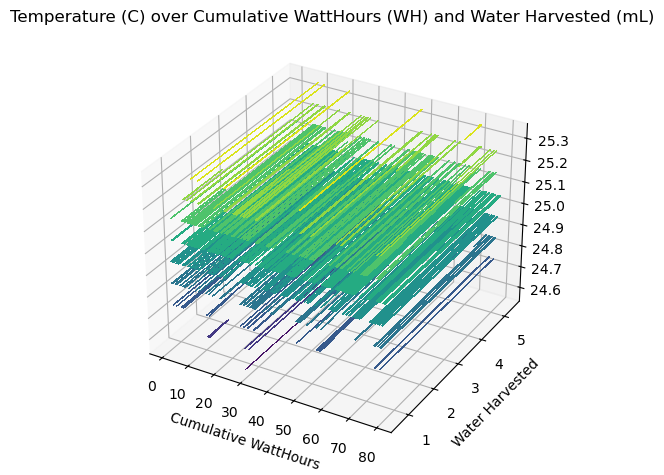

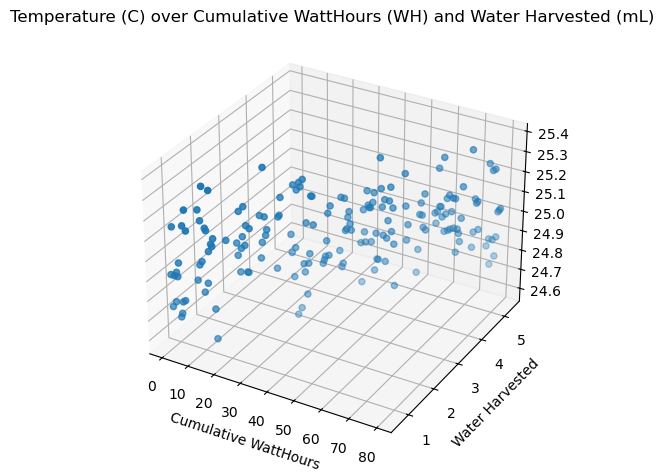

In [27]:
#Basic scatter plot
plt.plot(
    DP_x,
    DP_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = DepProto_Equations.equations_.query(
    f"loss < {2 * DepProto_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    DP_x,
    DepProto_Equations.predict(DP_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 100])
plt.ylim([0, 16])
analysis(
    [
        pd.to_numeric(
            DepProto_Dataframe["WattHours (WH)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DP_z,
        pd.to_numeric(
            DepProto_Dataframe["Amps (A)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DP_y,
    ]
)
print(DepProto_Equations.latex())

#3D scatterplot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours", loc="left")
plt.ylabel("Water Harvested")
fig.tight_layout()
DP_X, DP_Y = np.meshgrid(DP_x,DP_y)
DP_Z = sp.interpolate.griddata(np.column_stack((DP_x.reshape(-1,1),DP_y)), DP_z, (DP_X, DP_Y), method = "nearest")
plt.contourf(DP_x.reshape(-1),DP_y,DP_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(DP_x,DP_y,DP_z)